# FIE463 - Individual Assignment

## Optimal savings and portfolio choice

In [ ]:
# Preparations
# Modules
import numpy as np
import matplotlib.pyplot as plt

# Define default parameters
beta = .9                               # Discount factor
gamma = 4                               # Absolute risk aversion
sigma_sq = .16**2                       # Variance of risky return shock
mu = .04                                # Expected excess return
w = 1                                   # Initial wealth
rf = 1                                  # Risk-free gross return

sigma = np.sqrt(sigma_sq)               # Sigma from root of sigma_sq (Variance)

# Distribution for risky return
probs = np.array((1/6, 2/3, 1/6))        # Probabilities of eta
etas = np.array((-3**.5, 0, 3**.5))      # Values of eta (shock representing uncertainty)

exp_eta = etas @ probs

### Task 1

In [ ]:
# Verify that discretized risky return approximates the true mean and variance of the underlying normal distribution well
R = rf + mu + sigma * etas              # Risky return (vector)
er = rf + mu + sigma * exp_eta          # Expected gross risky return

var = probs @ (R - er)**2               # Variance of the risky return
std = np.sqrt(var)                      # Standard deviation of the risky return

eR_prem = er - rf                       # Expected risk premium
sharpe = eR_prem / std                  # Sharpe-ratio

# Comparisons
print(f'True mu: {mu} vs Calculated: {eR_prem:.2f}')
print(f'True variance: {var} vs Calculated: {std}')

True mu: 0.04 vs Calculated: 0.04
True variance: 0.0256 vs Calculated: 0.16


Values of expected excess return and variance for the discretized risky return are equal to those of the given parameters. 

The discretized risky return approximates the true mean and variance of the underlying normal distribution well.

### Task 2

In [3]:
def util(c, gamma):
    '''
    Return the flow utility of consumption for a given risk aversion
    '''
    u = -np.exp(-gamma * c)

    return u

In [4]:
# Scalar
c = .6
util(c, gamma)

np.float64(-0.09071795328941251)

In [5]:
# Array
c = np.array((0, .5, 1))
util(c, gamma)

array([-1.        , -0.13533528, -0.01831564])

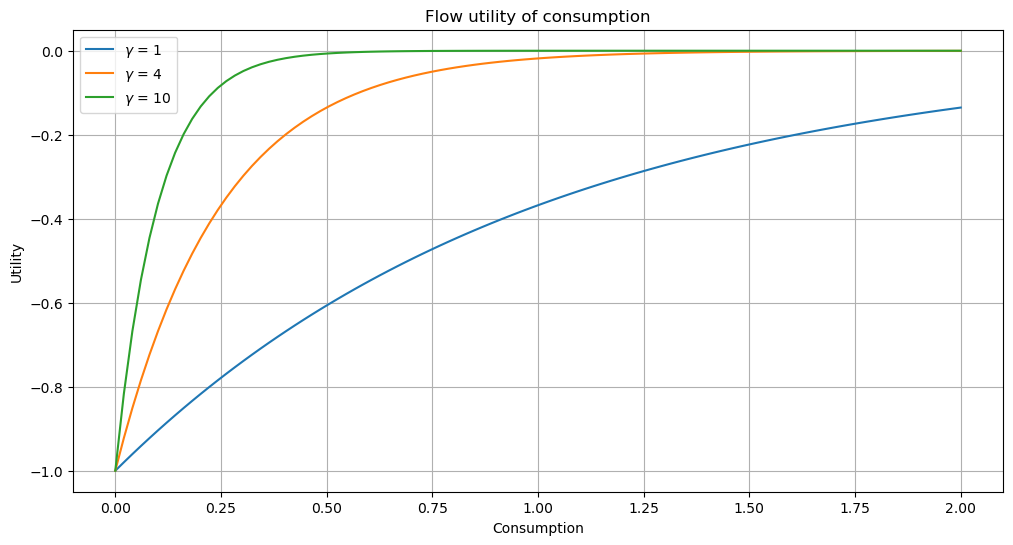

In [6]:
# Intialize parameters
c = np.linspace(0, 2, 100)
gammas = np.array((1, 4, 10))

# Intialize plot
plt.figure(figsize=(12,6))
plt.title('Flow utility of consumption')
plt.xlabel('Consumption')
plt.ylabel('Utility')
plt.grid()

# Loop over array of gammas to plot three separate curves
for g in gammas:
    u = util(c, g)
    plt.plot(c, u, label=fr'$\gamma$ = {g}')


# Display plot
_ = plt.legend()

### Task 3

In [56]:
def expected_util(s, alpha, beta=beta, gamma=gamma, sigma=sigma, mu=mu, w=w, etas=etas, probs=probs):
    '''
    Calculate the expected lifetime utility for given parameters
    '''
    S, A = np.meshgrid(s, alpha, indexing='ij')
    # Period 1 consumption from budget restraint - Consume whats left after chosen savings s
    c1 = w - S
    
    # Period 1 utility
    u1 = util(c1, gamma)
    
    # Risky returns
    R_lo = rf + mu + sigma * etas[0]
    R_mid = rf + mu + sigma * etas[1]
    R_hi = rf + mu + sigma * etas[2]

    # Period 2 consumption
    c2_lo = R_lo * A * S + rf * (1 - A) * S
    c2_mid = R_mid * A * S + rf * (1 - A) * S
    c2_hi = R_hi * A * S + rf * (1 - A) * S

    # Period 2 utilities
    u2_lo = util(c2_lo, gamma)
    u2_mid = util(c2_mid, gamma)
    u2_hi = util(c2_hi, gamma)

    # Period 2 expected utility
    eu2 = u2_lo * probs[0] + u2_mid * probs[1] + u2_hi * probs[2]
   
    # Expected lifetime utility
    eu_life = u1 + beta * eu2
    
    return eu_life

In [54]:
s = np.linspace(10**-6, w - 10**-6, 1_000)
alpha = np.linspace(0, 1, 1_000)
expected_util(s, alpha)

(1000, 1000)
(1000, 1000)
(1000, 1000)
(1000, 1000)


array([[-0.91831211, -0.91831211, -0.91831211, ..., -0.91831197,
        -0.91831197, -0.91831197],
       [-0.91478922, -0.91478907, -0.91478893, ..., -0.91464599,
        -0.91464585, -0.9146457 ],
       [-0.91128099, -0.9112807 , -0.91128042, ..., -0.91099621,
        -0.91099592, -0.91099564],
       ...,
       [-1.00863669, -1.00863404, -1.0086314 , ..., -1.00937205,
        -1.0093763 , -1.00938056],
       [-1.0125503 , -1.01254766, -1.01254502, ..., -1.01328696,
        -1.0132912 , -1.01329546],
       [-1.01648014, -1.0164775 , -1.01647488, ..., -1.01721808,
        -1.01722232, -1.01722657]], shape=(1000, 1000))

### Task 4

(200, 1)
(200, 1)
(200, 1)
(200, 1)
(200, 1)
(200, 1)
(200, 1)
(200, 1)
(200, 1)
(200, 1)
(200, 1)
(200, 1)


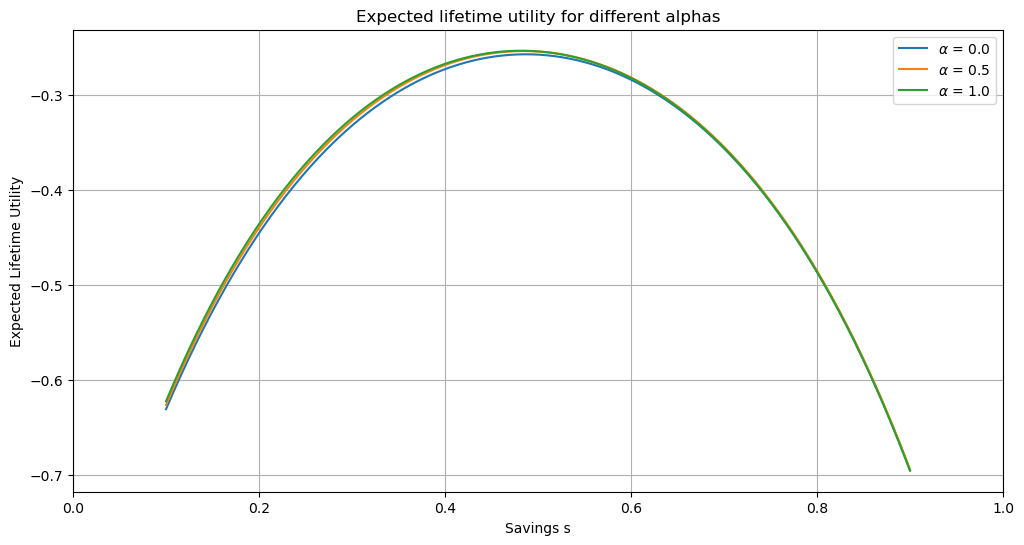

In [55]:
# Initialize parameters s and alpha
alphas = np.array((0, .5, 1))
s = np.linspace(.1, w - .1, 200)

# Initialize plot
plt.figure(figsize=(12,6))
plt.title('Expected lifetime utility for different alphas')
plt.xlabel('Savings s')
plt.ylabel('Expected Lifetime Utility')
plt.xlim((0,1))
plt.grid()

# Loop over alphas to plot
for a in alphas:
    eu_life = expected_util(s=s, alpha=a)
    plt.plot(s, eu_life.flatten(), label=fr'$\alpha$ = {a}')

_ = plt.legend()

The graph indicates that the optimal allocation of consumption between the two periods is about equal, regardless of the level of alpha. 

The three graphs being almost exactly equal should not be surprising, as the risk-aversion parameter is quite low at this moment.

### Task 5

In [57]:
def find_optimum(beta=beta, gamma=gamma, sigma=sigma, mu=mu, w=w, etas=etas, probs=probs):
    '''
    Find the optimal savings level and risky share to maximize expected utility
    '''
    # Initialize s and alpha as linear spaces
    s = np.linspace(10**-6, w - 10**-6, 1_000)
    alpha = np.linspace(0, 1, 1_000)

    # Calculate expected lifetime utility for all combinations
    eu_life = expected_util(s, alpha, beta=beta, gamma=gamma, sigma=sigma, mu=mu, w=w, etas=etas, probs=probs)

    # Find flat index of maximum
    idx_max = np.argmax(eu_life)

    # Convert flat index to (i_s, i_alpha)
    i_s, i_alpha = np.unravel_index(idx_max, eu_life.shape)

    # Optimal choices
    s_opt = s[i_s]
    a_opt = alpha[i_alpha]
    U_max = eu_life[i_s, i_alpha]

    return s_opt, a_opt, U_max

In [58]:
find_optimum()

(np.float64(0.4824825175175174),
 np.float64(0.8098098098098098),
 np.float64(-0.25279977091370276))

In [10]:
# Data type?
type(find_optimum())

tuple

### Task 6

In [59]:
# Collect values, and print
s_opt, a_opt, U_max = find_optimum()
print(f'Optimal saving: {s_opt:.3f}, Optimal alpha: {a_opt:.3f}, Max Expected Utility: {U_max:.3f}')

Optimal saving: 0.482, Optimal alpha: 0.810, Max Expected Utility: -0.253


### Task 7

In [60]:
# Define gammas
gammas = np.linspace(1, 10, 101)

# Define empty vector to store optimal shares
share_opt = np.empty_like(gammas)

# Loop over gammas enumerated (I use g so as to not overwrite the previous gamma = 4 for later!)
for i, g in enumerate(gammas):
    # Retrieve values
    s_opt, a_opt, U_max = find_optimum(gamma=g)
    
    # Add optimal share at each index i of the empty vector
    share_opt[i] += a_opt

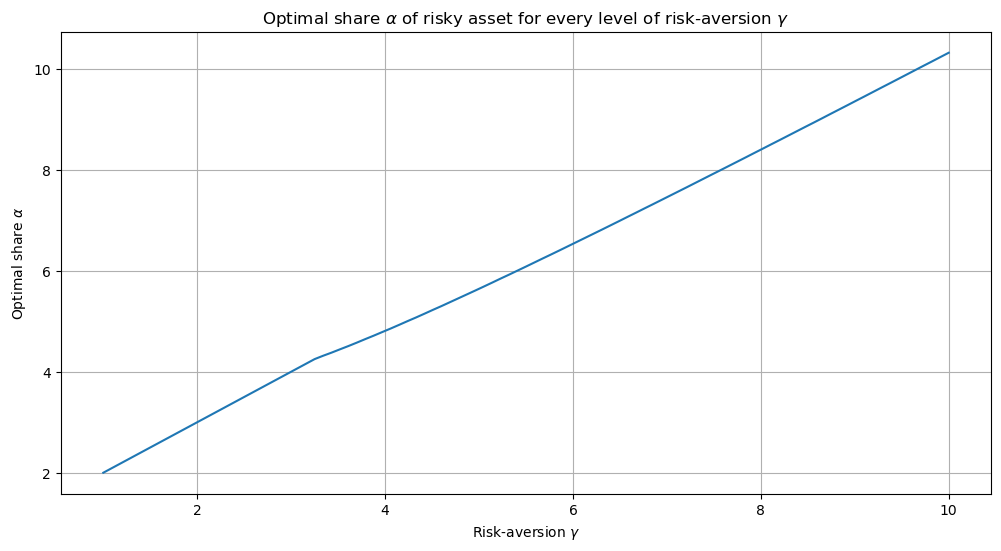

In [61]:
# Initialize plot
plt.figure(figsize=(12,6))
plt.title(r'Optimal share $\alpha$ of risky asset for every level of risk-aversion $\gamma$')
plt.xlabel(r'Risk-aversion $\gamma$')
plt.ylabel(r'Optimal share $\alpha$')
plt.grid()

# Plot optimal share on gammas
_ = plt.plot(gammas, share_opt)

...

### Task 8

In [66]:
# Define sigmas
sigmas = np.linspace(.01, .5, 101)

# Define empty vector to store optimal shares
share_opt = np.empty_like(sigmas)

# Loop over sigmas enumerated (sig so as not to overwrite sigma or s from earlier)
for i, sig in enumerate(sigmas):
    s_opt, a_opt, U_max = find_optimum(sigma=sig)
    share_opt[i] += a_opt

0


In [64]:
# Define sigmas
sigmas = np.linspace(.01, .5, 101)

# Define empty vector to store optimal shares
share_opt = np.empty_like(sigmas)

for i, sig in enumerate(sigmas):
    s_opt, a_opt, U_max = find_optimum(beta=beta, gamma=gamma, sigma=sig, mu=mu, w=w, etas=etas, probs=probs)
    share_opt[i] = a_opt
    print(f"sigma={sig:.3f}: s_opt={s_opt:.4f}, a_opt={a_opt:.4f}, dollar_amount={s_opt*a_opt:.4f}")

sigma=0.010: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.015: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.020: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.025: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.030: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.035: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.039: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.044: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.049: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.054: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.059: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.064: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.069: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.074: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.079: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.083: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.

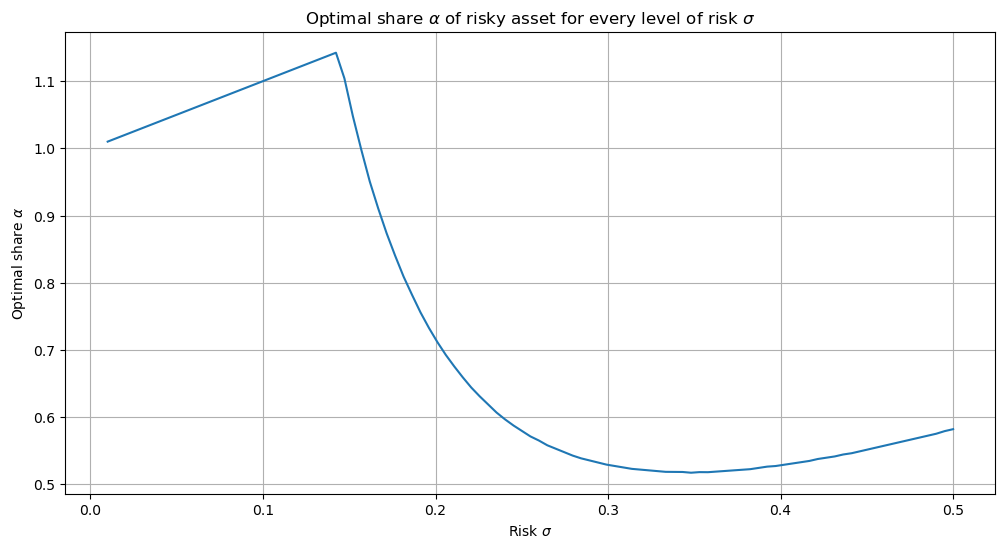

In [67]:
plt.figure(figsize=(12,6))
plt.title(r'Optimal share $\alpha$ of risky asset for every level of risk $\sigma$')
plt.xlabel(r'Risk $\sigma$')
plt.ylabel(r'Optimal share $\alpha$')
plt.grid()

_ = plt.plot(sigmas, share_opt)

In [17]:
print(f"Before loop: sigma = {sigma}")
for i, sig in enumerate(sigmas):
    s_opt, a_opt, U_max = find_optimum(sigma=sig)
    share_opt[i] += a_opt
    print(f"After iteration {i}: sigma = {sigma}")

Before loop: sigma = 0.16
After iteration 0: sigma = 0.16
After iteration 1: sigma = 0.16
After iteration 2: sigma = 0.16
After iteration 3: sigma = 0.16
After iteration 4: sigma = 0.16
After iteration 5: sigma = 0.16
After iteration 6: sigma = 0.16
After iteration 7: sigma = 0.16
After iteration 8: sigma = 0.16
After iteration 9: sigma = 0.16
After iteration 10: sigma = 0.16
After iteration 11: sigma = 0.16
After iteration 12: sigma = 0.16
After iteration 13: sigma = 0.16
After iteration 14: sigma = 0.16
After iteration 15: sigma = 0.16
After iteration 16: sigma = 0.16
After iteration 17: sigma = 0.16
After iteration 18: sigma = 0.16
After iteration 19: sigma = 0.16
After iteration 20: sigma = 0.16
After iteration 21: sigma = 0.16
After iteration 22: sigma = 0.16
After iteration 23: sigma = 0.16
After iteration 24: sigma = 0.16
After iteration 25: sigma = 0.16
After iteration 26: sigma = 0.16
After iteration 27: sigma = 0.16
After iteration 28: sigma = 0.16
After iteration 29: sigma =

In [36]:
def find_optimum(beta=beta, gamma=gamma, sigma=sigma, mu=mu, w=w, etas=etas, probs=probs):
    """
    Find the optimal savings level and risky share to maximize expected utility.
    """
    # Initialize s and alpha as linear spaces
    s_vec = np.linspace(10**-6, w - 10**-6, 1_000)
    alpha_vec = np.linspace(0, 1, 1_000)
    
    # Create meshgrid for all combinations
    S, Alpha = np.meshgrid(s_vec, alpha_vec, indexing='ij')
    # S.shape = (1000, 1000), Alpha.shape = (1000, 1000)
    
    # Flatten to evaluate
    S_flat = S.flatten()
    Alpha_flat = Alpha.flatten()
    
    # Calculate expected lifetime utility for all combinations
    eu_life_flat = expected_util(S_flat, Alpha_flat, beta=beta, gamma=gamma, sigma=sigma, mu=mu, w=w, etas=etas, probs=probs)
    
    # Reshape back to 2D
    eu_life = eu_life_flat.reshape(1000, 1000)
    
    # Find maximum
    i_s, i_alpha = np.unravel_index(np.argmax(eu_life), eu_life.shape)
    
    s_opt = s_vec[i_s]
    a_opt = alpha_vec[i_alpha]
    U_max = eu_life[i_s, i_alpha]
    
    return s_opt, a_opt, U_max

In [37]:
# Define sigmas
sigmas = np.linspace(.01, .5, 101)

# Define empty vector to store optimal shares
share_opt = np.empty_like(sigmas)

for i, sig in enumerate(sigmas):
    s_opt, a_opt, U_max = find_optimum(beta=beta, gamma=gamma, sigma=sig, mu=mu, w=w, etas=etas, probs=probs)
    share_opt[i] = a_opt
    print(f"sigma={sig:.3f}: s_opt={s_opt:.4f}, a_opt={a_opt:.4f}, dollar_amount={s_opt*a_opt:.4f}")

sigma=0.010: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.015: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.020: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.025: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.030: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.035: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.039: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.044: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.049: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.054: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.059: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.064: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.069: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.074: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.079: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.083: s_opt=0.4825, a_opt=1.0000, dollar_amount=0.4825
sigma=0.

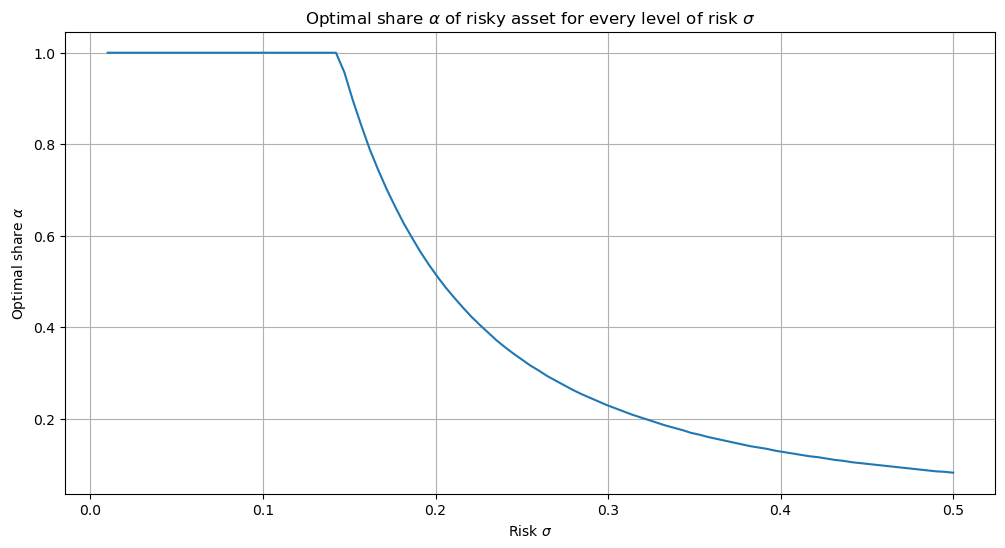

In [38]:
plt.figure(figsize=(12,6))
plt.title(r'Optimal share $\alpha$ of risky asset for every level of risk $\sigma$')
plt.xlabel(r'Risk $\sigma$')
plt.ylabel(r'Optimal share $\alpha$')
plt.grid()

_ = plt.plot(sigmas, share_opt)